<a href="https://colab.research.google.com/github/vaishnavivahile/-Superstore-Sales-Analysis-/blob/main/SuperstoreSales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/Sample - Superstore.csv', encoding='latin-1')
print(df.shape)
print(df.head())

(9994, 21)
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       4

In [2]:
# Data types
print(df.dtypes)

# Null values
print(df.isnull().sum())

# Basic stats
print(df.describe())

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
            Row ID   Postal Code         Sales   

In [3]:
# Date columns
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

print(df['Order Date'].dtype)
print(df['Ship Date'].dtype)

datetime64[ns]
datetime64[ns]


In [4]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

print(df[['Order Date', 'Year', 'Month']].head())

  Order Date  Year  Month
0 2016-11-08  2016     11
1 2016-11-08  2016     11
2 2016-06-12  2016      6
3 2015-10-11  2015     10
4 2015-10-11  2015     10


   Year        Sales
0  2014  484247.4981
1  2015  470532.5090
2  2016  609205.5980
3  2017  733215.2552


/tmp/ipykernel_7587/3154331040.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=yearly_sales, x='Year', y='Sales', palette='Blues_d')


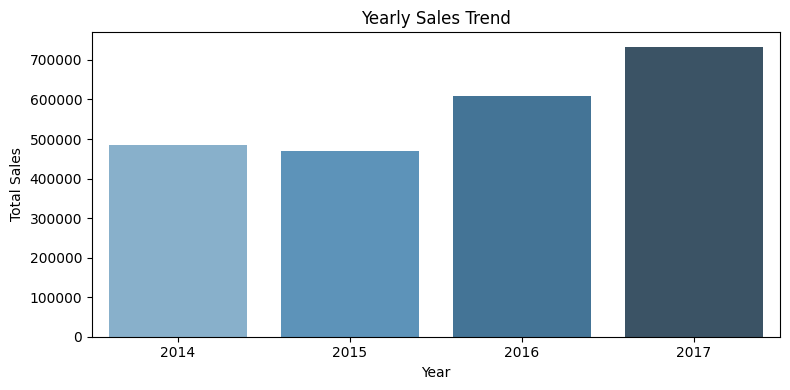

In [5]:
#Yearly Sales Trend
yearly_sales = df.groupby('Year')['Sales'].sum().reset_index()
print(yearly_sales)

plt.figure(figsize=(8,4))
sns.barplot(data=yearly_sales, x='Year', y='Sales', palette='Blues_d')
plt.title('Yearly Sales Trend')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

          Category       Profit
0        Furniture   18451.2728
1  Office Supplies  122490.8008
2       Technology  145454.9481


/tmp/ipykernel_7587/2834289489.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_profit, x='Category', y='Profit', palette='Set2')


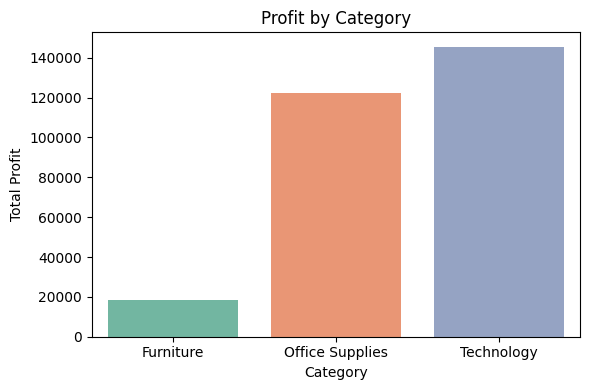

In [6]:
#Profit by Category
category_profit = df.groupby('Category')['Profit'].sum().reset_index()
print(category_profit)

plt.figure(figsize=(6,4))
sns.barplot(data=category_profit, x='Category', y='Profit', palette='Set2')
plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')
plt.tight_layout()
plt.show()

In [7]:
category_sales = df.groupby('Category')[['Sales', 'Profit']].sum().reset_index()
print(category_sales)

          Category        Sales       Profit
0        Furniture  741999.7953   18451.2728
1  Office Supplies  719047.0320  122490.8008
2       Technology  836154.0330  145454.9481


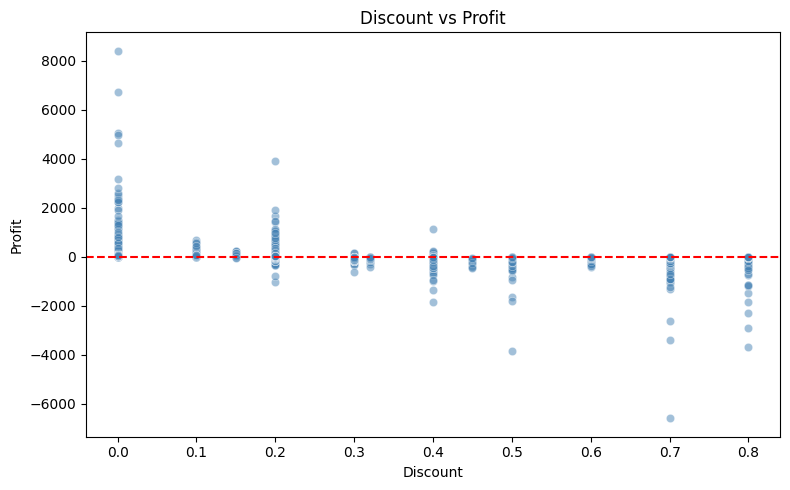

In [8]:
#Discount vs Profit
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.5, color='steelblue')
plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.axhline(y=0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

    Region        Sales       Profit
0  Central  501239.8908   39706.3625
1     East  678781.2400   91522.7800
2    South  391721.9050   46749.4303
3     West  725457.8245  108418.4489


/tmp/ipykernel_7587/1565336401.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_profit, x='Region', y='Profit', palette='Set3')


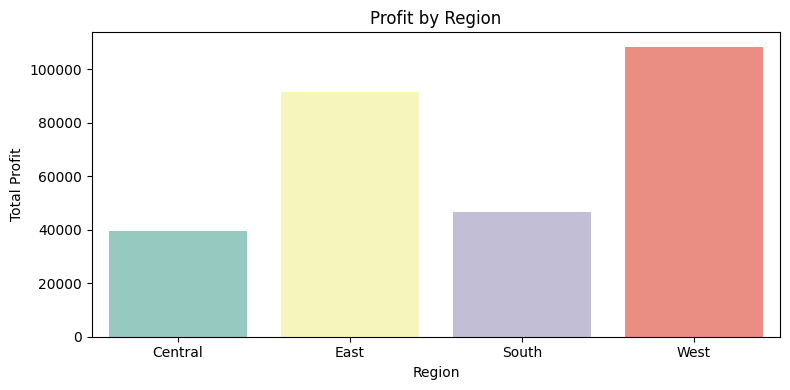

In [9]:
#Profit by Region
region_profit = df.groupby('Region')[['Sales', 'Profit']].sum().reset_index()
print(region_profit)

plt.figure(figsize=(8,4))
sns.barplot(data=region_profit, x='Region', y='Profit', palette='Set3')
plt.title('Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit')
plt.tight_layout()
plt.show()

In [10]:
region_discount = df.groupby('Region')['Discount'].mean().reset_index()
print(region_discount)

    Region  Discount
0  Central  0.240353
1     East  0.145365
2    South  0.147253
3     West  0.109335


In [11]:
df.to_csv('superstore_clean.csv', index=False)